# Model Comparison: VGG19, DenseNet121, ResNet50, MobileNet

This notebook compares the performance of 4 different deep learning models on the leaf classification task.


In [1]:
# Import libraries
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns

# Configure GPU
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"[OK] GPU memory growth enabled for {len(gpus)} GPU(s)")
    except RuntimeError as e:
        print(e)


[OK] GPU memory growth enabled for 1 GPU(s)


In [2]:
# Load test dataset
print("Loading test dataset...")
test_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

test_set = test_datagen.flow_from_directory(
    'removed background',
    target_size=(224, 224),
    batch_size=16,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=42
)

class_names = list(test_set.class_indices.keys())
print(f"\nTest set loaded: {test_set.samples} images belonging to {len(class_names)} classes")


Loading test dataset...
Found 1046 images belonging to 20 classes.

Test set loaded: 1046 images belonging to 20 classes


In [3]:
# Load all 4 models
print("Loading models...")

models = {}
model_names = ['VGG19', 'DenseNet121', 'ResNet50', 'MobileNet']
model_files = {
    'VGG19': 'VGG19_best_model.keras',
    'DenseNet121': 'DenseNet121_best_model.keras',
    'ResNet50': 'ResNet50_best_model.keras',
    'MobileNet': 'MobileNet_best_model.keras'
}

for name in model_names:
    try:
        models[name] = load_model(model_files[name])
        print(f"✓ {name} loaded successfully")
    except Exception as e:
        print(f"✗ Failed to load {name}: {e}")

print(f"\nTotal models loaded: {len(models)}")


Loading models...
✓ VGG19 loaded successfully
✓ DenseNet121 loaded successfully
✓ ResNet50 loaded successfully
✓ MobileNet loaded successfully

Total models loaded: 4


In [5]:
# Evaluate each model on test set
print("Evaluating models on test set...")
print("=" * 60)

results = {}

for name, model in models.items():
    print(f"\nEvaluating {name}...")
    test_set.reset()
    
    # Get predictions
    y_pred_probs = model.predict(test_set, verbose=0)
    y_pred = np.argmax(y_pred_probs, axis=1)
    
    # Get true labels - handle both numpy arrays and tensors
    test_set.reset()
    true_categories_list = []
    for x, y in test_set:
        # Convert to numpy if it's a tensor, otherwise use as is
        if hasattr(y, 'numpy'):
            y_np = y.numpy()
        else:
            y_np = np.array(y)
        true_categories_list.append(y_np)
        if len(true_categories_list) * test_set.batch_size >= test_set.samples:
            break
    true_categories = np.concatenate(true_categories_list, axis=0)
    y_true = np.argmax(true_categories, axis=1)
    
    # Calculate accuracy
    accuracy = accuracy_score(y_true, y_pred)
    
    # Store results
    results[name] = {
        'accuracy': accuracy,
        'y_true': y_true,
        'y_pred': y_pred,
        'classification_report': classification_report(y_true, y_pred, target_names=class_names, output_dict=True, zero_division=0)
    }
    
    print(f"{name} Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

print("\n" + "=" * 60)


Evaluating models on test set...

Evaluating VGG19...
VGG19 Accuracy: 0.7132 (71.32%)

Evaluating DenseNet121...
DenseNet121 Accuracy: 0.8270 (82.70%)

Evaluating ResNet50...
ResNet50 Accuracy: 0.2648 (26.48%)

Evaluating MobileNet...
MobileNet Accuracy: 0.8767 (87.67%)



In [6]:
# Create comparison table
print("\nModel Comparison Summary")
print("=" * 60)

comparison_data = []
for name, result in results.items():
    report = result['classification_report']
    comparison_data.append({
        'Model': name,
        'Accuracy': f"{result['accuracy']:.4f} ({result['accuracy']*100:.2f}%)",
        'Macro Avg Precision': f"{report['macro avg']['precision']:.4f}",
        'Macro Avg Recall': f"{report['macro avg']['recall']:.4f}",
        'Macro Avg F1-Score': f"{report['macro avg']['f1-score']:.4f}"
    })

df = pd.DataFrame(comparison_data)
print(df.to_string(index=False))



Model Comparison Summary
      Model        Accuracy Macro Avg Precision Macro Avg Recall Macro Avg F1-Score
      VGG19 0.7132 (71.32%)              0.7200           0.7143             0.7060
DenseNet121 0.8270 (82.70%)              0.8308           0.8368             0.8232
   ResNet50 0.2648 (26.48%)              0.1845           0.2581             0.1939
  MobileNet 0.8767 (87.67%)              0.8914           0.8817             0.8763


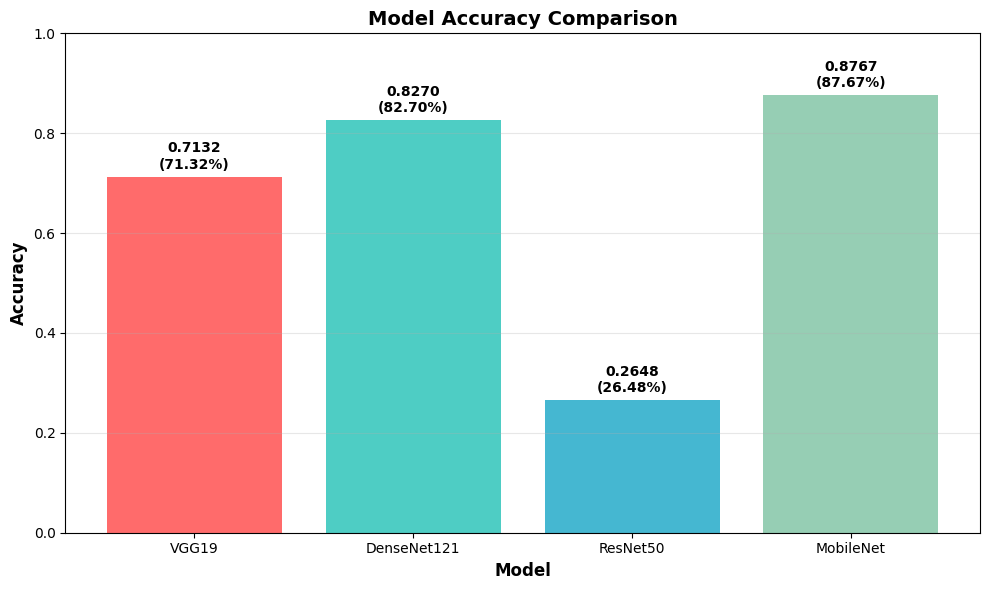

In [7]:
# Visualize accuracy comparison
plt.figure(figsize=(10, 6))
model_names_list = list(results.keys())
accuracies = [results[name]['accuracy'] for name in model_names_list]

bars = plt.bar(model_names_list, accuracies, color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4'])
plt.xlabel('Model', fontsize=12, fontweight='bold')
plt.ylabel('Accuracy', fontsize=12, fontweight='bold')
plt.title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
plt.ylim([0, 1])
plt.grid(axis='y', alpha=0.3)

# Add accuracy values on top of bars
for i, (bar, acc) in enumerate(zip(bars, accuracies)):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{acc:.4f}\n({acc*100:.2f}%)', 
             ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()


In [8]:
# Detailed classification report for each model
for name, result in results.items():
    print(f"\n{'='*60}")
    print(f"{name} - Detailed Classification Report")
    print(f"{'='*60}")
    print(classification_report(result['y_true'], result['y_pred'], target_names=class_names, zero_division=0))



VGG19 - Detailed Classification Report
                precision    recall  f1-score   support

      Aloevera       0.77      0.85      0.81        60
          Amla       0.21      0.07      0.11        40
        Bamboo       0.82      0.88      0.85        52
        Bhrami       0.92      0.76      0.83        62
    Bringaraja       0.74      0.70      0.72        40
        Castor       0.93      0.90      0.92        63
        Coffee       0.75      1.00      0.86        45
     Coriender       1.00      0.91      0.95        57
         Curry       0.80      0.38      0.51        64
    Eucalyptus       0.90      0.64      0.75        42
        Ginger       0.85      0.88      0.86        40
         Guava       0.47      0.56      0.51        62
         Henna       0.59      0.51      0.55        45
      Hibiscus       0.18      0.24      0.21        58
         Lemon       0.74      0.64      0.69        55
          Mint       0.60      0.62      0.61        69
       

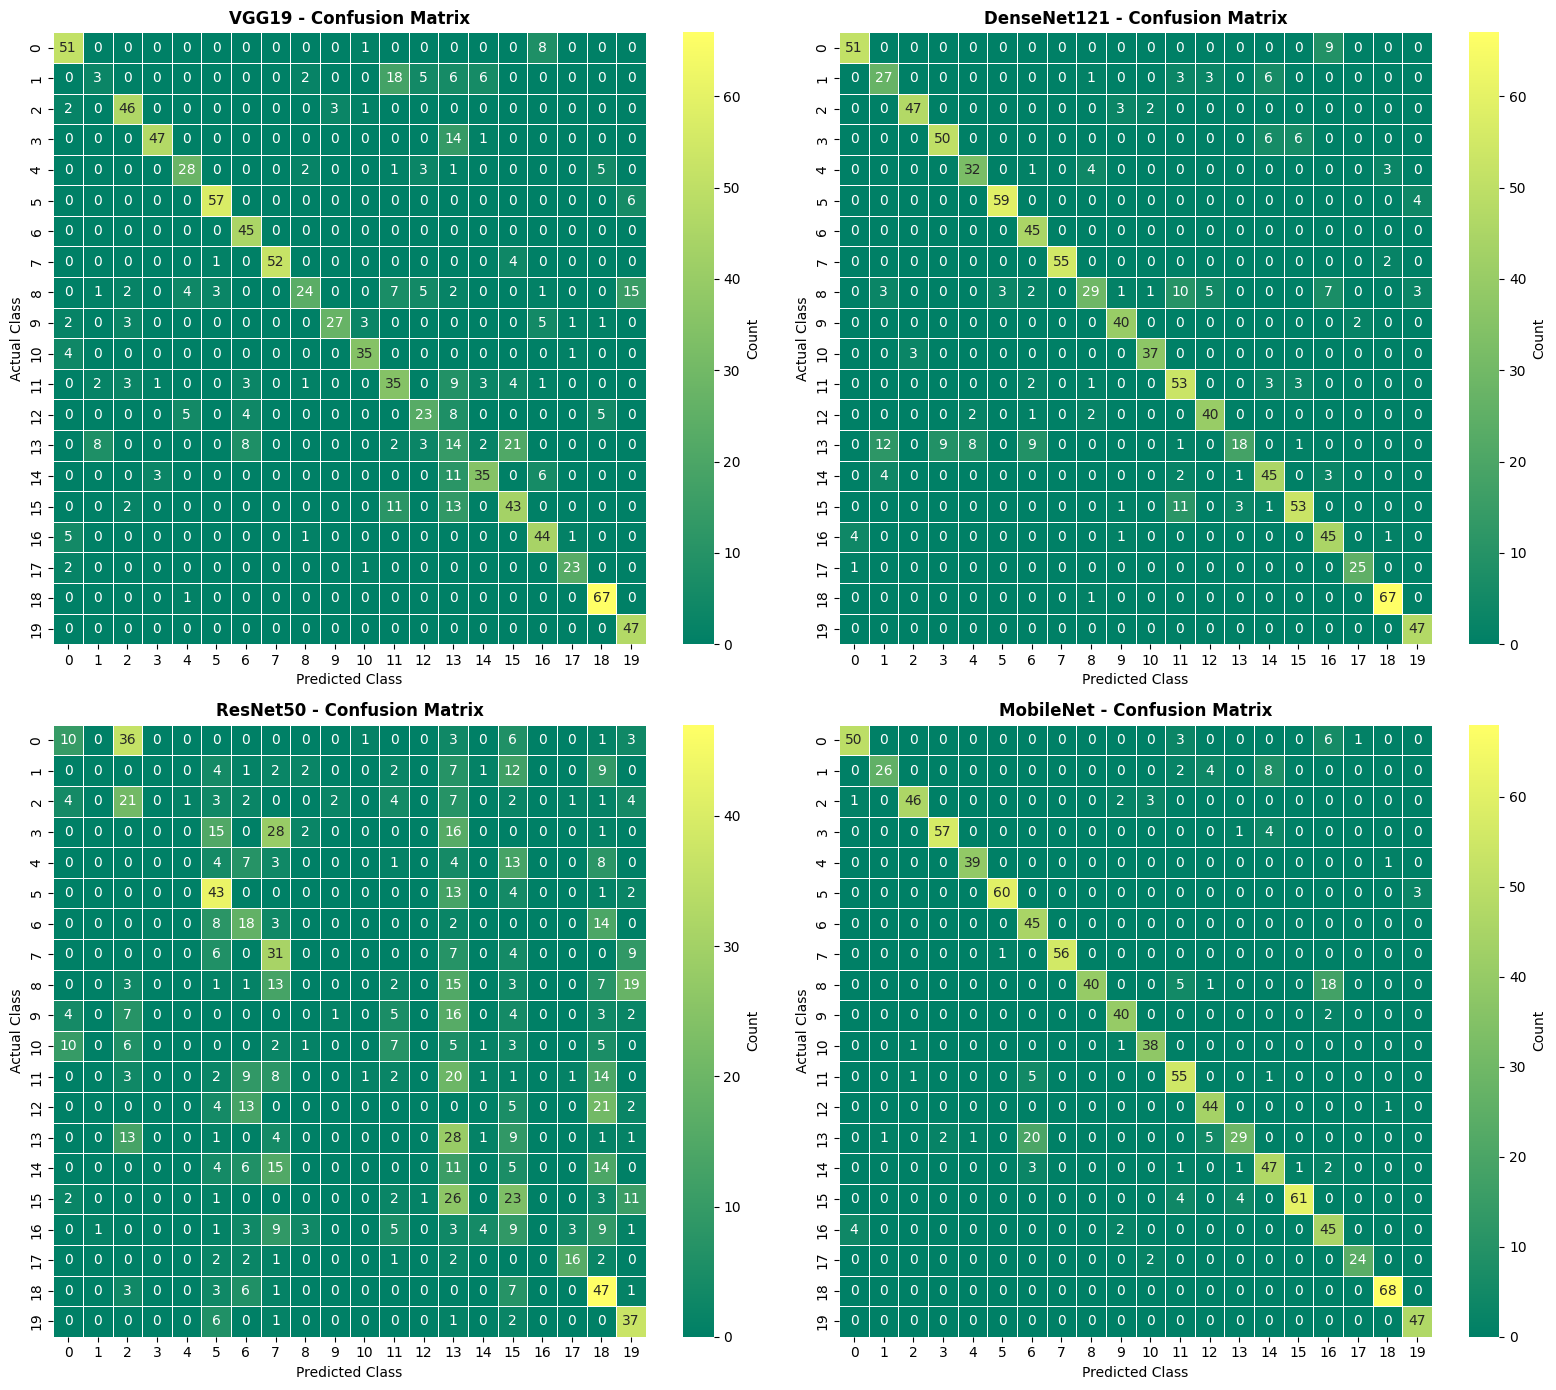

In [9]:
# Confusion matrices for all models
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes = axes.ravel()

for idx, (name, result) in enumerate(results.items()):
    cm = confusion_matrix(result['y_true'], result['y_pred'])
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='summer', ax=axes[idx], 
                cbar_kws={'label': 'Count'}, linewidths=0.5)
    axes[idx].set_title(f'{name} - Confusion Matrix', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Predicted Class', fontsize=10)
    axes[idx].set_ylabel('Actual Class', fontsize=10)

plt.tight_layout()
plt.show()


In [10]:
# Save results to CSV
model_names_list = list(results.keys())
accuracies = [results[name]['accuracy'] for name in model_names_list]

results_df = pd.DataFrame({
    'Model': model_names_list,
    'Accuracy': accuracies
})
results_df.to_csv('model_comparison_results.csv', index=False)
print("Results saved to 'model_comparison_results.csv'")


Results saved to 'model_comparison_results.csv'
